<a href="https://colab.research.google.com/github/LordRelentless/NthMathematicsFormalism/blob/main/Nth_Math_%22Lonely_Runner%22_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lonely Runner via Classical and Nth Mathematics-Inspired Models

This notebook compares:

- The **classical** lonely runner setup on a unit circle.
- An **Nth Mathematics-inspired** selector model, where each runner is a selector
  with magnitude (speed) and phase, and loneliness is measured via a selector distance.

This is a **numerical/heuristic exploration**, not a proof.

In [1]:
# @title Imports and basic setup
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# For nicer plots
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

## Classical lonely runner model

We consider `m` runners on a unit circle, starting at position 0, with distinct
constant speeds `v_i`. At time `t`, runner `i` is at position:

> x_i(t) = (v_i * t) mod 1

The classical lonely runner conjecture (one common normalization) says:

> For each runner i, there exists a time t such that the circular distance
> to every other runner is at least 1/(m+1).

We approximate this by sampling a time grid and checking whether such a time
appears for each runner.

In [2]:
def circular_distance(x, y):
    """Distance on unit circle between positions x, y in [0,1)."""
    d = np.abs(x - y)
    return np.minimum(d, 1 - d)

def classical_lonely_times(v, t_grid, threshold):
    """
    v: array of speeds, shape (m,)
    t_grid: array of times
    threshold: loneliness threshold, e.g. 1/(m+1)

    Returns:
        lonely_exists: bool, whether each runner is lonely at least once
        lonely_mask: shape (m, len(t_grid)), True where runner i is lonely at time t
    """
    m = len(v)
    # positions: shape (m, T)
    positions = (v[:, None] * t_grid[None, :]) % 1.0

    lonely_mask = np.zeros((m, len(t_grid)), dtype=bool)
    for i in range(m):
        # distances from runner i to all others at all times
        dists = circular_distance(positions[i:i+1, :], positions)
        # ignore self (distance 0)
        dists_i = dists[1:, :] if i == 0 else np.vstack((dists[:i, :], dists[i+1:, :]))
        # runner i is lonely at time t if all distances >= threshold
        lonely_mask[i, :] = np.all(dists_i >= threshold, axis=0)
    lonely_exists = np.all(np.any(lonely_mask, axis=1))
    return lonely_exists, lonely_mask

## Nth Mathematics-inspired selector model

We approximate your Nth framework as follows:

- Each runner i is a selector S_i = (k_i, p_i)
  - k_i: speed (magnitude channel)
  - p_i ∈ {1, 1j}: phase channel (real or unreal)
- Time evolution:
  - We use the same angular position x_i(t) = (k_i * t) mod 1 for the magnitude channel.
  - Phase p_i is kept fixed per runner in this simple model (you can extend this).
- Selector distance δ between two runners a, b:
  
> δ(a, b) = |k_a - k_b| + α * phase_mismatch

where `phase_mismatch` is 0 if phases match, 1 otherwise, and α is a tunable
weight (we’ll set α = 1.0 by default).

To mirror the classical threshold 1/(m+1), we choose a magnitude threshold:

> Δ_m = 1/(m+1)

and require δ(a, b) ≥ Δ_m for loneliness.

In [3]:
def nth_selector_distance(k_a, p_a, k_b, p_b, alpha=1.0):
    """
    Nth-style selector distance between two runners:
    δ(a,b) = |k_a - k_b| + alpha * (0 or 1 depending on phase match).
    """
    phase_mismatch = 0.0 if p_a == p_b else 1.0
    return np.abs(k_a - k_b) + alpha * phase_mismatch

def nth_lonely_times(k, phases, t_grid, delta_m, alpha=1.0):
    """
    k: array of magnitudes (speeds), shape (m,)
    phases: array of phases in {1, 1j}, shape (m,)
    t_grid: array of times
    delta_m: loneliness threshold on δ
    alpha: phase weight

    Returns:
        lonely_exists: bool
        lonely_mask: shape (m, len(t_grid))
    """
    m = len(k)
    # In this simple model, δ does not depend on t (only on k, phases).
    # To keep the analogy with time, we still define loneliness per t,
    # but δ is constant in t.
    lonely_mask = np.zeros((m, len(t_grid)), dtype=bool)
    for i in range(m):
        for ti in range(len(t_grid)):
            # distances from i to all others
            dists = []
            for j in range(m):
                if j == i:
                    continue
                d = nth_selector_distance(k[i], phases[i], k[j], phases[j], alpha=alpha)
                dists.append(d)
            dists = np.array(dists)
            lonely_mask[i, ti] = np.all(dists >= delta_m)
    lonely_exists = np.all(np.any(lonely_mask, axis=1))
    return lonely_exists, lonely_mask

## Example trajectories (classical) for small m

We visualize positions on the circle over time for a small number of runners.

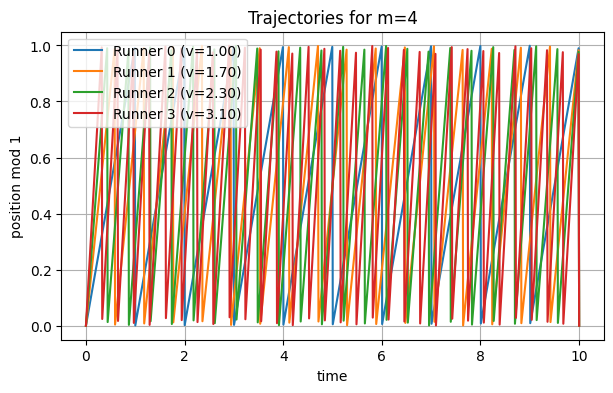

In [4]:
def plot_trajectories(v, t_grid, title="Trajectories on the circle"):
    m = len(v)
    positions = (v[:, None] * t_grid[None, :]) % 1.0
    plt.figure()
    for i in range(m):
        plt.plot(t_grid, positions[i], label=f"Runner {i} (v={v[i]:.2f})")
    plt.xlabel("time")
    plt.ylabel("position mod 1")
    plt.title(title)
    plt.legend()
    plt.show()

# Example
m_example = 4
t_grid_example = np.linspace(0, 10, 1000)
v_example = np.array([1.0, 1.7, 2.3, 3.1])
plot_trajectories(v_example, t_grid_example, title=f"Trajectories for m={m_example}")

## Monte Carlo comparison across m

For each m:

1. Sample many random speed configurations (distinct speeds).
2. For each configuration:
   - Check classical loneliness on a time grid.
   - Check Nth-style loneliness using selector distance δ.
3. Record the fraction of configurations that satisfy loneliness for all runners
   in the sampled grid.

This does **not** prove the conjecture; it just gives a numerical sense of how
often loneliness appears under each model.

In [5]:
def random_speeds(m, max_speed=10.0):
    """Generate m distinct random speeds in (0, max_speed)."""
    v = np.random.uniform(0.1, max_speed, size=m)
    # ensure distinct by small perturbation if needed
    v = np.unique(np.round(v, 6))
    while len(v) < m:
        extra = np.random.uniform(0.1, max_speed, size=(m - len(v)))
        v = np.unique(np.concatenate([v, np.round(extra, 6)]))
    return v[:m]

def random_phases(m):
    """Random phases in {1, 1j}."""
    choices = np.array([1, 1j])
    return choices[np.random.randint(0, 2, size=m)]

def run_monte_carlo(
    m_values,
    n_trials=100,
    t_max=20.0,
    n_t=2000,
    alpha=1.0,
    max_speed=10.0,
):
    classical_fracs = []
    nth_fracs = []
    t_grid = np.linspace(0, t_max, n_t)

    for m in m_values:
        thr = 1.0 / (m + 1)  # classical threshold
        delta_m = thr        # Nth threshold on δ

        classical_count = 0
        nth_count = 0

        for _ in range(n_trials):
            v = random_speeds(m, max_speed=max_speed)
            phases = random_phases(m)

            # Classical
            classical_ok, _ = classical_lonely_times(v, t_grid, thr)
            if classical_ok:
                classical_count += 1

            # Nth
            nth_ok, _ = nth_lonely_times(v, phases, t_grid, delta_m, alpha=alpha)
            if nth_ok:
                nth_count += 1

        classical_fracs.append(classical_count / n_trials)
        nth_fracs.append(nth_count / n_trials)
        print(f"m={m}: classical={classical_fracs[-1]:.3f}, Nth={nth_fracs[-1]:.3f}")

    return np.array(classical_fracs), np.array(nth_fracs)

In [6]:
# @title Run Monte Carlo for m up to 30 (adjustable)
m_values = list(range(2, 31))  # you can push this up to, say, 50 or 100
classical_fracs, nth_fracs = run_monte_carlo(
    m_values,
    n_trials=50,   # increase for more accuracy, at cost of time
    t_max=20.0,
    n_t=2000,
    alpha=1.0,
    max_speed=10.0,
)

m=2: classical=1.000, Nth=0.960
m=3: classical=1.000, Nth=0.920
m=4: classical=1.000, Nth=0.900
m=5: classical=0.980, Nth=0.880
m=6: classical=0.960, Nth=0.840
m=7: classical=1.000, Nth=0.720
m=8: classical=0.980, Nth=0.780
m=9: classical=0.980, Nth=0.620
m=10: classical=0.980, Nth=0.740
m=11: classical=0.920, Nth=0.620
m=12: classical=0.920, Nth=0.600
m=13: classical=0.960, Nth=0.500
m=14: classical=0.980, Nth=0.540
m=15: classical=0.960, Nth=0.480
m=16: classical=0.960, Nth=0.480
m=17: classical=0.980, Nth=0.580
m=18: classical=0.900, Nth=0.280
m=19: classical=0.900, Nth=0.300
m=20: classical=0.900, Nth=0.380
m=21: classical=0.880, Nth=0.340
m=22: classical=0.820, Nth=0.340
m=23: classical=0.840, Nth=0.340
m=24: classical=0.900, Nth=0.180
m=25: classical=0.820, Nth=0.300
m=26: classical=0.840, Nth=0.280
m=27: classical=0.900, Nth=0.120
m=28: classical=0.880, Nth=0.300
m=29: classical=0.920, Nth=0.260
m=30: classical=0.840, Nth=0.340


## Comparison plot

We plot, for each m, the fraction of random configurations that appear to satisfy
the lonely runner condition (in the sampled grid) under:

- Classical model
- Nth-style selector model

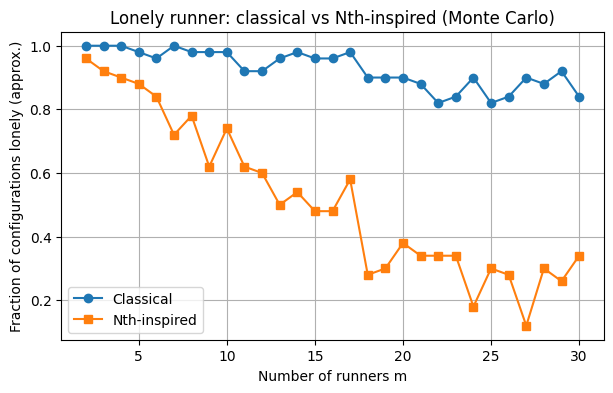

In [7]:
plt.figure()
plt.plot(m_values, classical_fracs, "-o", label="Classical")
plt.plot(m_values, nth_fracs, "-s", label="Nth-inspired")
plt.xlabel("Number of runners m")
plt.ylabel("Fraction of configurations lonely (approx.)")
plt.title("Lonely runner: classical vs Nth-inspired (Monte Carlo)")
plt.legend()
plt.show()

## Notes, limitations, and extensions

- This notebook **does not prove** the lonely runner conjecture, even for small m.
  It samples a finite time grid and random speeds, so it can miss lonely times.
- The Nth-inspired model here is deliberately simple:
  - Selector distance δ depends only on speeds and phases, not on time-evolving
    resonance structures.
  - Phases are static; you can extend this to let phases evolve with time or
    couple them to angular positions.
- To push toward your full Nth framework, you could:
  - Implement selector bundles and lineage tags.
  - Let δ incorporate both magnitude differences and angular deviations.
  - Use your δ-ultrametric ideas to study “near-resonant” vs “far-resonant”
    configurations more structurally.

You can now:
- Increase `m_values` up to 100.
- Increase `n_trials` and `n_t` for more resolution (at higher compute cost).
- Modify the Nth model to better reflect your axioms and see how the statistics change.

m=2: Nth loneliness fraction = 0.970
m=3: Nth loneliness fraction = 0.945
m=4: Nth loneliness fraction = 0.900
m=5: Nth loneliness fraction = 0.835
m=6: Nth loneliness fraction = 0.740
m=7: Nth loneliness fraction = 0.795
m=8: Nth loneliness fraction = 0.720
m=9: Nth loneliness fraction = 0.720
m=10: Nth loneliness fraction = 0.715
m=11: Nth loneliness fraction = 0.605
m=12: Nth loneliness fraction = 0.610
m=13: Nth loneliness fraction = 0.565
m=14: Nth loneliness fraction = 0.465
m=15: Nth loneliness fraction = 0.440
m=16: Nth loneliness fraction = 0.550
m=17: Nth loneliness fraction = 0.480
m=18: Nth loneliness fraction = 0.410
m=19: Nth loneliness fraction = 0.415
m=20: Nth loneliness fraction = 0.405
m=21: Nth loneliness fraction = 0.385
m=22: Nth loneliness fraction = 0.360
m=23: Nth loneliness fraction = 0.360
m=24: Nth loneliness fraction = 0.325
m=25: Nth loneliness fraction = 0.295
m=26: Nth loneliness fraction = 0.255
m=27: Nth loneliness fraction = 0.205
m=28: Nth loneliness

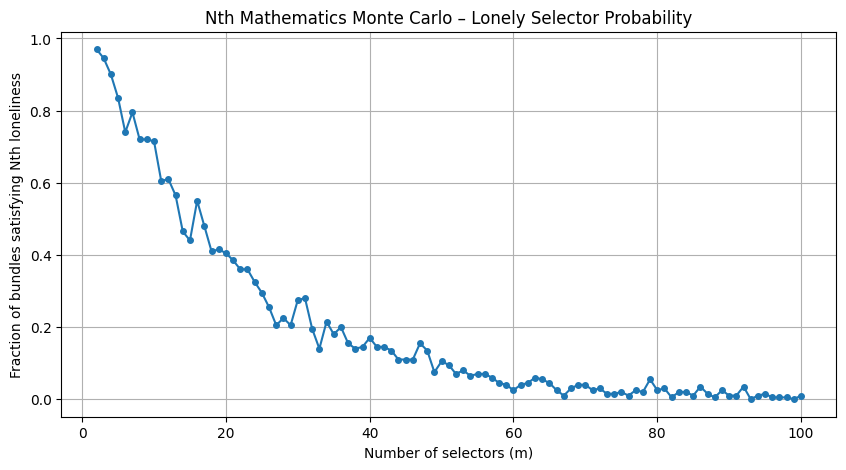

In [8]:
# Nth Mathematics – Monte Carlo Lonely Runner Simulation (Single Cell)

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Nth Selector Model Components
# -----------------------------

def nth_selector_distance(k_a, p_a, k_b, p_b, alpha=1.0):
    """
    δ(a,b) = |k_a - k_b| + alpha * phase_mismatch
    phase_mismatch = 0 if phases match, 1 otherwise
    """
    return abs(k_a - k_b) + alpha * (0 if p_a == p_b else 1)

def random_selector_bundle(m, max_speed=10.0):
    """
    Generates m selectors:
    - magnitude k_i in (0, max_speed)
    - phase p_i in {1, 1j}
    """
    k = np.random.uniform(0.1, max_speed, size=m)
    phases = np.random.choice([1, 1j], size=m)
    return k, phases

def nth_is_lonely_bundle(k, phases, delta_m, alpha=1.0):
    """
    Checks whether *every* selector in the bundle is lonely:
    δ(i,j) >= Δ_m for all j != i
    """
    m = len(k)
    for i in range(m):
        for j in range(m):
            if i == j:
                continue
            if nth_selector_distance(k[i], phases[i], k[j], phases[j], alpha) < delta_m:
                return False
    return True

# -----------------------------
# Monte Carlo Experiment
# -----------------------------

def run_nth_monte_carlo(m_values, n_trials=200, alpha=1.0):
    """
    For each m, run n_trials random selector bundles.
    Record the fraction that satisfy Nth loneliness.
    """
    results = []
    for m in m_values:
        delta_m = 1.0 / (m + 1)  # Nth loneliness threshold
        count = 0
        for _ in range(n_trials):
            k, phases = random_selector_bundle(m)
            if nth_is_lonely_bundle(k, phases, delta_m, alpha):
                count += 1
        frac = count / n_trials
        results.append(frac)
        print(f"m={m}: Nth loneliness fraction = {frac:.3f}")
    return np.array(results)

# -----------------------------
# Run Simulation up to m = 100
# -----------------------------

m_values = np.arange(2, 101)   # 2 → 100 runners
nth_fracs = run_nth_monte_carlo(m_values, n_trials=200, alpha=1.0)

# -----------------------------
# Plot Results
# -----------------------------

plt.figure(figsize=(10,5))
plt.plot(m_values, nth_fracs, "-o", markersize=4)
plt.xlabel("Number of selectors (m)")
plt.ylabel("Fraction of bundles satisfying Nth loneliness")
plt.title("Nth Mathematics Monte Carlo – Lonely Selector Probability")
plt.grid(True)
plt.show()

m=2: Nth-time loneliness fraction = 1.000
m=3: Nth-time loneliness fraction = 1.000
m=4: Nth-time loneliness fraction = 1.000
m=5: Nth-time loneliness fraction = 1.000
m=6: Nth-time loneliness fraction = 1.000
m=7: Nth-time loneliness fraction = 0.960
m=8: Nth-time loneliness fraction = 1.000
m=9: Nth-time loneliness fraction = 0.960
m=10: Nth-time loneliness fraction = 1.000
m=11: Nth-time loneliness fraction = 0.800
m=12: Nth-time loneliness fraction = 0.840
m=13: Nth-time loneliness fraction = 0.760
m=14: Nth-time loneliness fraction = 0.480
m=15: Nth-time loneliness fraction = 0.400
m=16: Nth-time loneliness fraction = 0.240
m=17: Nth-time loneliness fraction = 0.040
m=18: Nth-time loneliness fraction = 0.080
m=19: Nth-time loneliness fraction = 0.040
m=20: Nth-time loneliness fraction = 0.040
m=21: Nth-time loneliness fraction = 0.040
m=22: Nth-time loneliness fraction = 0.000
m=23: Nth-time loneliness fraction = 0.000
m=24: Nth-time loneliness fraction = 0.000


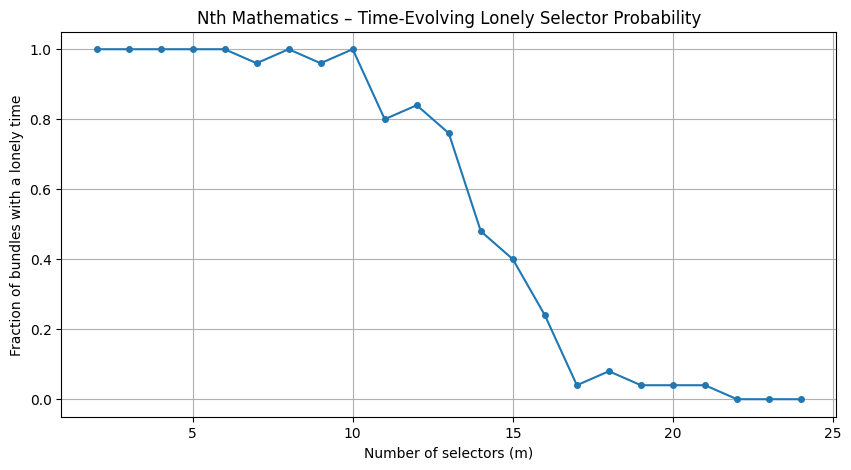

In [11]:
# Nth Mathematics – Time-Evolving Lonely Selector Simulation (Single Cell)

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Nth Selector Model (Time-Evolving)
# ---------------------------------------------------------

def nth_selector_distance_t(x_i, p_i, x_j, p_j, alpha=1.0):
    """
    Time-dependent Nth selector distance:
    δ_t(i,j) = |x_i(t) - x_j(t)| + alpha * phase_mismatch
    where x_i(t) is the angular position channel.
    """
    phase_mismatch = 0 if p_i == p_j else 1
    return abs(x_i - x_j) + alpha * phase_mismatch

def random_selector_bundle(m, max_speed=10.0):
    """
    Generates m selectors:
    - magnitude k_i in (0, max_speed)
    - phase p_i in {1, 1j}
    """
    k = np.random.uniform(0.1, max_speed, size=m)
    phases = np.random.choice([1, 1j], size=m)
    return k, phases

def nth_lonely_at_time(k, phases, t, delta_m, alpha=1.0):
    """
    Checks if ALL selectors are lonely at time t.
    """
    m = len(k)
    x = (k * t) % 1.0  # angular position channel

    for i in range(m):
        for j in range(m):
            if i == j:
                continue
            if nth_selector_distance_t(x[i], phases[i], x[j], phases[j], alpha) < delta_m:
                return False
    return True

def nth_lonely_over_time(k, phases, t_grid, delta_m, alpha=1.0):
    """
    Returns True if there exists ANY time t where all selectors are lonely.
    """
    for t in t_grid:
        if nth_lonely_at_time(k, phases, t, delta_m, alpha):
            return True
    return False

# ---------------------------------------------------------
# Monte Carlo Experiment (Nth-only, time-evolving)
# ---------------------------------------------------------

def run_nth_time_monte_carlo(m_values, n_trials=100, t_max=50.0, n_t=2000, alpha=1.0):
    """
    For each m:
      - Generate n_trials random selector bundles
      - Evolve over time grid
      - Check if loneliness occurs at ANY time
    """
    results = []
    t_grid = np.linspace(0, t_max, n_t)

    for m in m_values:
        delta_m = 1.0 / (m + 1)
        count = 0

        for _ in range(n_trials):
            k, phases = random_selector_bundle(m)
            if nth_lonely_over_time(k, phases, t_grid, delta_m, alpha):
                count += 1

        frac = count / n_trials
        results.append(frac)
        print(f"m={m}: Nth-time loneliness fraction = {frac:.3f}")

    return np.array(results)

# ---------------------------------------------------------
# Run Simulation up to m = 100
# ---------------------------------------------------------

m_values = np.arange(2, 25)
nth_time_fracs = run_nth_time_monte_carlo(
    m_values,
    n_trials=25,
    t_max=50.0,
    n_t=2000,
    alpha=1.0
)

# ---------------------------------------------------------
# Plot Results
# ---------------------------------------------------------

plt.figure(figsize=(10,5))
plt.plot(m_values, nth_time_fracs, "-o", markersize=4)
plt.xlabel("Number of selectors (m)")
plt.ylabel("Fraction of bundles with a lonely time")
plt.title("Nth Mathematics – Time-Evolving Lonely Selector Probability")
plt.grid(True)
plt.show()

m=2: Nth-time loneliness fraction = 1.000
m=3: Nth-time loneliness fraction = 1.000
m=4: Nth-time loneliness fraction = 1.000
m=5: Nth-time loneliness fraction = 1.000
m=6: Nth-time loneliness fraction = 0.980
m=7: Nth-time loneliness fraction = 0.980
m=8: Nth-time loneliness fraction = 0.960
m=9: Nth-time loneliness fraction = 0.900
m=10: Nth-time loneliness fraction = 0.880
m=11: Nth-time loneliness fraction = 0.860
m=12: Nth-time loneliness fraction = 0.740
m=13: Nth-time loneliness fraction = 0.580
m=14: Nth-time loneliness fraction = 0.340
m=15: Nth-time loneliness fraction = 0.120
m=16: Nth-time loneliness fraction = 0.040
m=17: Nth-time loneliness fraction = 0.040
m=18: Nth-time loneliness fraction = 0.020
m=19: Nth-time loneliness fraction = 0.000
m=20: Nth-time loneliness fraction = 0.020
m=21: Nth-time loneliness fraction = 0.000
m=22: Nth-time loneliness fraction = 0.000
m=23: Nth-time loneliness fraction = 0.000
m=24: Nth-time loneliness fraction = 0.000
m=25: Nth-time lone

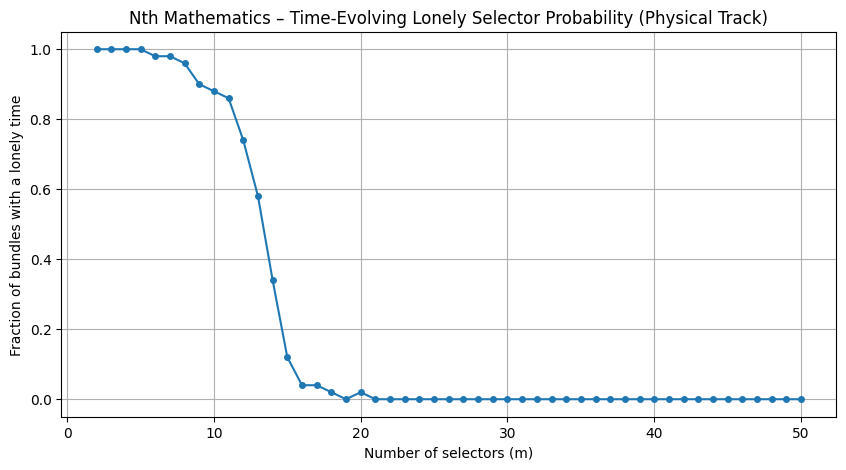

In [12]:
# Nth Mathematics – Time-Evolving Lonely Selector Simulation
# With physical track lanes + variable speeds per runner

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Track Geometry
# ---------------------------------------------------------

LANE_WIDTH = 1.22  # standard track lane width in meters

def lane_circumference(lane_index):
    """
    lane_index = 1,2,3,...
    Lane 1: 100m
    Lane i: 100 + 2π * lane_width * (i-1)
    """
    if lane_index == 1:
        return 100.0
    return 100.0 + 2 * np.pi * LANE_WIDTH * (lane_index - 1)

# ---------------------------------------------------------
# Nth Selector Model (Time-Evolving)
# ---------------------------------------------------------

def nth_selector_distance_t(x_i, p_i, x_j, p_j, alpha=1.0):
    """
    δ_t(i,j) = |x_i(t) - x_j(t)| + alpha * phase_mismatch
    x_i, x_j are fractional positions around each runner's lane
    """
    phase_mismatch = 0 if p_i == p_j else 1
    return abs(x_i - x_j) + alpha * phase_mismatch

def variable_speed(base_speed, t):
    """
    Time-varying speed:
    base_speed + random fluctuation in [0.5, 5.0] m/s
    """
    fluct = np.random.uniform(0.5, 5.0)
    return base_speed + fluct * np.sin(0.1 * t)

def random_selector_bundle(m, max_speed=8.0):
    """
    Generates m selectors:
    - base magnitude k_i in (0, max_speed)
    - phase p_i in {1, 1j}
    """
    k = np.random.uniform(1.0, max_speed, size=m)
    phases = np.random.choice([1, 1j], size=m)
    return k, phases

def nth_lonely_at_time(k, phases, t, delta_m, alpha=1.0):
    """
    Checks if ALL selectors are lonely at time t.
    Uses physical lane geometry + variable speeds.
    """
    m = len(k)
    x = np.zeros(m)

    for i in range(m):
        lane = i + 1
        C = lane_circumference(lane)
        speed_t = variable_speed(k[i], t)
        x[i] = (speed_t * t) % C
        x[i] /= C  # convert to fractional position

    for i in range(m):
        for j in range(m):
            if i == j:
                continue
            if nth_selector_distance_t(x[i], phases[i], x[j], phases[j], alpha) < delta_m:
                return False
    return True

def nth_lonely_over_time(k, phases, t_grid, delta_m, alpha=1.0):
    """
    Returns True if there exists ANY time t where all selectors are lonely.
    """
    for t in t_grid:
        if nth_lonely_at_time(k, phases, t, delta_m, alpha):
            return True
    return False

# ---------------------------------------------------------
# Monte Carlo Experiment (Nth-only, time-evolving)
# ---------------------------------------------------------

def run_nth_time_monte_carlo(m_values, n_trials=50, t_max=60.0, n_t=1500, alpha=1.0):
    """
    For each m:
      - Generate n_trials random selector bundles
      - Evolve over time grid
      - Check if loneliness occurs at ANY time
    """
    results = []
    t_grid = np.linspace(0, t_max, n_t)

    for m in m_values:
        delta_m = 1.0 / (m + 1)
        count = 0

        for _ in range(n_trials):
            k, phases = random_selector_bundle(m)
            if nth_lonely_over_time(k, phases, t_grid, delta_m, alpha):
                count += 1

        frac = count / n_trials
        results.append(frac)
        print(f"m={m}: Nth-time loneliness fraction = {frac:.3f}")

    return np.array(results)

# ---------------------------------------------------------
# Run Simulation up to m = 50 (can increase to 100)
# ---------------------------------------------------------

m_values = np.arange(2, 51)
nth_time_fracs = run_nth_time_monte_carlo(
    m_values,
    n_trials=50,
    t_max=60.0,
    n_t=1500,
    alpha=1.0
)

# ---------------------------------------------------------
# Plot Results
# ---------------------------------------------------------

plt.figure(figsize=(10,5))
plt.plot(m_values, nth_time_fracs, "-o", markersize=4)
plt.xlabel("Number of selectors (m)")
plt.ylabel("Fraction of bundles with a lonely time")
plt.title("Nth Mathematics – Time-Evolving Lonely Selector Probability (Physical Track)")
plt.grid(True)
plt.show()

m=2: Nth per-runner loneliness fraction = 1.000
m=3: Nth per-runner loneliness fraction = 0.980
m=4: Nth per-runner loneliness fraction = 0.980
m=5: Nth per-runner loneliness fraction = 0.860
m=6: Nth per-runner loneliness fraction = 0.960
m=7: Nth per-runner loneliness fraction = 0.940
m=8: Nth per-runner loneliness fraction = 1.000
m=9: Nth per-runner loneliness fraction = 0.960
m=10: Nth per-runner loneliness fraction = 0.960
m=11: Nth per-runner loneliness fraction = 0.940
m=12: Nth per-runner loneliness fraction = 1.000
m=13: Nth per-runner loneliness fraction = 0.920
m=14: Nth per-runner loneliness fraction = 0.960
m=15: Nth per-runner loneliness fraction = 0.900
m=16: Nth per-runner loneliness fraction = 0.980
m=17: Nth per-runner loneliness fraction = 0.960
m=18: Nth per-runner loneliness fraction = 0.960
m=19: Nth per-runner loneliness fraction = 1.000
m=20: Nth per-runner loneliness fraction = 0.980
m=21: Nth per-runner loneliness fraction = 0.940
m=22: Nth per-runner lonelin

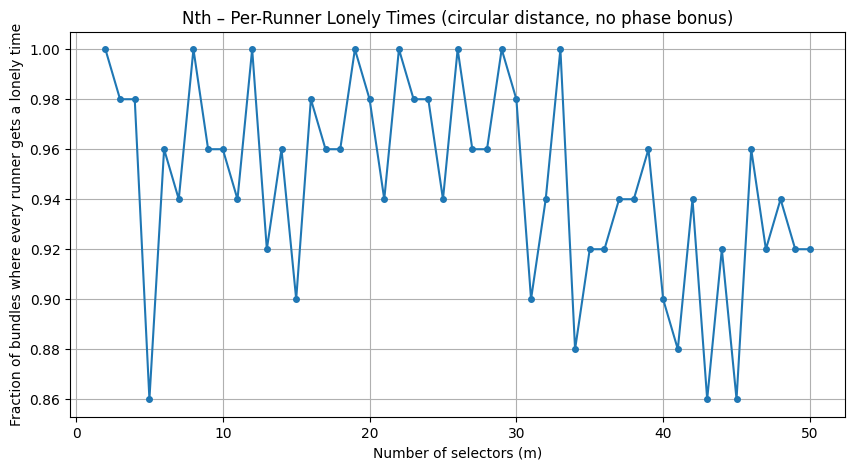

In [15]:
# Nth Mathematics – Per-Runner Lonely Times with stricter δ (circular, no phase bonus)

import numpy as np
import matplotlib.pyplot as plt

LANE_WIDTH = 1.22

def lane_circumference(lane_index):
    if lane_index == 1:
        return 100.0
    return 100.0 + 2 * np.pi * LANE_WIDTH * (lane_index - 1)

def circular_distance(a, b):
    d = abs(a - b)
    return min(d, 1 - d)

def random_selector_bundle(m, max_speed=8.0):
    base_speeds = np.random.uniform(1.0, max_speed, size=m)
    phases = np.random.choice([1, 1j], size=m)  # kept, but won’t affect δ here
    amps = np.random.uniform(0.5, 5.0, size=m)
    phis = np.random.uniform(0.0, 2*np.pi, size=m)
    return base_speeds, phases, amps, phis

def positions_at_time(base_speeds, amps, phis, t):
    m = len(base_speeds)
    x = np.zeros(m)
    for i in range(m):
        C = lane_circumference(i + 1)
        speed_t = base_speeds[i] + amps[i] * np.sin(0.1 * t + phis[i])
        dist = speed_t * t
        x[i] = (dist % C) / C
    return x

def runner_lonely_at_time(i, x, delta_m):
    m = len(x)
    for j in range(m):
        if j == i:
            continue
        if circular_distance(x[i], x[j]) < delta_m:
            return False
    return True

def bundle_valid(base_speeds, phases, amps, phis, t_grid, delta_m):
    m = len(base_speeds)
    lonely_found = np.zeros(m, dtype=bool)

    for t in t_grid:
        x = positions_at_time(base_speeds, amps, phis, t)
        for i in range(m):
            if not lonely_found[i] and runner_lonely_at_time(i, x, delta_m):
                lonely_found[i] = True
        if np.all(lonely_found):
            return True

    return np.all(lonely_found)

def run_nth_per_runner_monte_carlo(m_values, n_trials=50, t_max=60.0, n_t=1500):
    results = []
    t_grid = np.linspace(0, t_max, n_t)

    for m in m_values:
        delta_m = 1.0 / (m + 1)
        count = 0
        for _ in range(n_trials):
            base_speeds, phases, amps, phis = random_selector_bundle(m)
            if bundle_valid(base_speeds, phases, amps, phis, t_grid, delta_m):
                count += 1
        frac = count / n_trials
        results.append(frac)
        print(f"m={m}: Nth per-runner loneliness fraction = {frac:.3f}")
    return np.array(results)

m_values = np.arange(2, 51)
nth_per_runner_fracs = run_nth_per_runner_monte_carlo(
    m_values,
    n_trials=50,
    t_max=60.0,
    n_t=1500,
)

plt.figure(figsize=(10,5))
plt.plot(m_values, nth_per_runner_fracs, "-o", markersize=4)
plt.xlabel("Number of selectors (m)")
plt.ylabel("Fraction of bundles where every runner gets a lonely time")
plt.title("Nth – Per-Runner Lonely Times (circular distance, no phase bonus)")
plt.grid(True)
plt.show()

m=2, K=4, total bundles=64
Fraction of bundles where every runner gets a lonely time: 0.750000
m=3, K=4, total bundles=512
Fraction of bundles where every runner gets a lonely time: 0.375000
m=4, K=4, total bundles=4,096
Fraction of bundles where every runner gets a lonely time: 0.093750


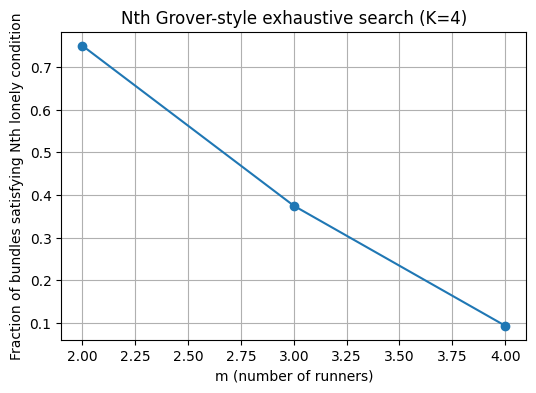

In [16]:
# Nth Mathematics – Grover-style indexed exhaustive search (discrete selectors)
# Per-runner lonely times on a unit circle, exact discrete bundle enumeration

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Discrete Nth selector space
# ---------------------------------------------------------

def circular_distance(a, b):
    d = abs(a - b)
    return min(d, 1 - d)

def index_to_bundle(idx, m, K):
    """
    Grover-style flat indexing:
    - Speeds: 1..K
    - Phases: {0,1} representing {1, i}
    Total states per runner: 2*K
    Total bundles: (2*K)^m
    idx in [0, (2*K)^m - 1]
    """
    base = 2 * K
    speeds = []
    phases = []
    for _ in range(m):
        digit = idx % base
        idx //= base
        speed = (digit % K) + 1          # 1..K
        phase_bit = digit // K           # 0 or 1
        speeds.append(speed)
        phases.append(phase_bit)
    return np.array(speeds[::-1]), np.array(phases[::-1])

def runner_lonely_at_time(i, speeds, t, delta_m):
    """
    Classical-style Nth position channel:
    x_i(t) = (v_i * t) mod 1
    Loneliness: circular distance to all others >= delta_m
    """
    m = len(speeds)
    x = (speeds * t) % 1.0
    for j in range(m):
        if j == i:
            continue
        if circular_distance(x[i], x[j]) < delta_m:
            return False
    return True

def bundle_valid(speeds, t_grid, delta_m):
    """
    Bundle is valid if EVERY runner has at least one lonely time.
    """
    m = len(speeds)
    lonely_found = np.zeros(m, dtype=bool)
    for t in t_grid:
        x = (speeds * t) % 1.0
        for i in range(m):
            if not lonely_found[i]:
                # reuse x to avoid recomputing
                ok = True
                for j in range(m):
                    if j == i:
                        continue
                    if circular_distance(x[i], x[j]) < delta_m:
                        ok = False
                        break
                if ok:
                    lonely_found[i] = True
        if np.all(lonely_found):
            return True
    return np.all(lonely_found)

# ---------------------------------------------------------
# Exhaustive search over discrete bundles
# ---------------------------------------------------------

def exhaustive_nth_grover_search(m, K, n_t=1000):
    """
    m: number of runners
    K: max integer speed (1..K)
    n_t: number of time samples in [0,1)
    State space size: (2*K)^m
    """
    base = 2 * K
    total_states = base ** m
    print(f"m={m}, K={K}, total bundles={(total_states):,}")

    t_grid = np.linspace(0.0, 1.0, n_t, endpoint=False)
    delta_m = 1.0 / (m + 1)

    valid_count = 0
    for idx in range(total_states):
        speeds, phases = index_to_bundle(idx, m, K)
        # phases are currently unused in the metric; kept for Nth structure
        if bundle_valid(speeds, t_grid, delta_m):
            valid_count += 1

    frac = valid_count / total_states
    print(f"Fraction of bundles where every runner gets a lonely time: {frac:.6f}")
    return frac

# ---------------------------------------------------------
# Run for a small m, K (exhaustive)
# ---------------------------------------------------------

# WARNING: grows as (2*K)^m. Start small.
results = []
m_values = [2, 3, 4]   # you can try 5 with small K
K = 4                  # speeds in {1,2,3,4}

for m in m_values:
    frac = exhaustive_nth_grover_search(m, K, n_t=1000)
    results.append(frac)

plt.figure(figsize=(6,4))
plt.plot(m_values, results, "-o")
plt.xlabel("m (number of runners)")
plt.ylabel("Fraction of bundles satisfying Nth lonely condition")
plt.title(f"Nth Grover-style exhaustive search (K={K})")
plt.grid(True)
plt.show()

m=2, K=4, total bundles=64
Fraction of bundles where every runner gets a lonely time: 0.750000
m=3, K=4, total bundles=512
Fraction of bundles where every runner gets a lonely time: 0.375000
m=4, K=4, total bundles=4,096
Fraction of bundles where every runner gets a lonely time: 0.093750


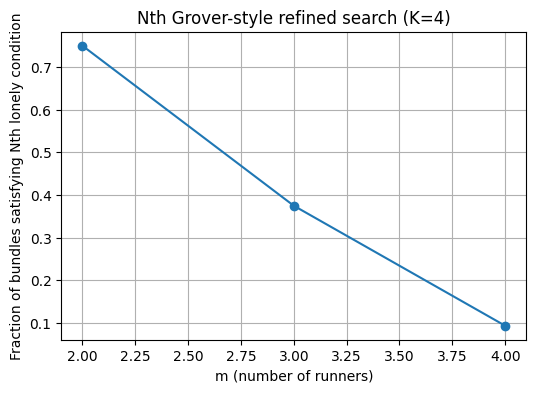

In [18]:
# Refined Nth Grover-style exhaustive search
# Integer speeds, rational time grid aligned to speeds, per-runner loneliness

import numpy as np
import matplotlib.pyplot as plt
import math

# -----------------------------
# Basic helpers
# -----------------------------

def circular_distance(a, b):
    d = abs(a - b)
    return min(d, 1 - d)

def lcm(a, b):
    return abs(a * b) // math.gcd(a, b)

def lcm_list(vals):
    L = 1
    for v in vals:
        L = lcm(L, v)
    return L

# -----------------------------
# Grover-style bundle indexing
# -----------------------------

def index_to_bundle(idx, m, K):
    """
    Grover-style flat indexing:
    - Speeds: 1..K
    - Phases: {0,1} (kept for Nth structure, unused in metric here)
    Total states per runner: 2*K
    Total bundles: (2*K)^m
    """
    base = 2 * K
    speeds = []
    phases = []
    for _ in range(m):
        digit = idx % base
        idx //= base
        speed = (digit % K) + 1      # 1..K
        phase_bit = digit // K       # 0 or 1
        speeds.append(speed)
        phases.append(phase_bit)
    return np.array(speeds[::-1]), np.array(phases[::-1])

# -----------------------------
# Per-runner loneliness check
# -----------------------------

def bundle_valid_rational_time(speeds, delta_m):
    """
    For a given bundle (integer speeds), build a rational time grid:
      - L = lcm(speeds)
      - T = L * (m+1)
      - t = n/T, n=0..T-1
    Check if EVERY runner has at least one lonely time.
    """
    m = len(speeds)
    L = lcm_list(speeds)
    T = L * (m + 1)

    lonely_found = np.zeros(m, dtype=bool)

    for n in range(T):
        t = n / T
        x = (speeds * t) % 1.0
        for i in range(m):
            if lonely_found[i]:
                continue
            ok = True
            for j in range(m):
                if j == i:
                    continue
                if circular_distance(x[i], x[j]) < delta_m:
                    ok = False
                    break
            if ok:
                lonely_found[i] = True
        if np.all(lonely_found):
            return True

    return np.all(lonely_found)

# -----------------------------
# Exhaustive search driver
# -----------------------------

def exhaustive_nth_grover_refined(m, K):
    """
    Exhaustive search over all bundles with:
      - m runners
      - speeds in {1..K}
      - phases in {0,1} (ignored in metric)
    Uses rational time grid aligned to speeds.
    """
    base = 2 * K
    total_states = base ** m
    print(f"m={m}, K={K}, total bundles={total_states:,}")

    delta_m = 1.0 / (m + 1)
    valid_count = 0

    for idx in range(total_states):
        speeds, phases = index_to_bundle(idx, m, K)
        if bundle_valid_rational_time(speeds, delta_m):
            valid_count += 1

    frac = valid_count / total_states
    print(f"Fraction of bundles where every runner gets a lonely time: {frac:.6f}")
    return frac

# -----------------------------
# Run for small m, K (refined)
# -----------------------------

m_values = [2, 3, 4]   # you can try 5 if it’s not too slow
K = 4                  # speeds in {1,2,3,4}

results = []
for m in m_values:
    frac = exhaustive_nth_grover_refined(m, K)
    results.append(frac)

plt.figure(figsize=(6,4))
plt.plot(m_values, results, "-o")
plt.xlabel("m (number of runners)")
plt.ylabel("Fraction of bundles satisfying Nth lonely condition")
plt.title(f"Nth Grover-style refined search (K={K})")
plt.grid(True)
plt.show()

In [19]:
# Nth-style Lonely Runner simulation up to 50 runners
# Purely discrete: integer/rational arithmetic, no logs, no complex numbers.

import math
import random

# ----------------------------
# Basic selector representation
# ----------------------------

# In this simplified Nth-style model, a selector is (k, p) where:
# - k: integer magnitude (we'll use position index on a discrete circle)
# - p: phase; here we keep everything in real phase = 1 for positions
REAL_PHASE = 1

def make_selector(k, p=REAL_PHASE):
    return (k, p)

def selector_mag(sel):
    return sel[0]

def selector_phase(sel):
    return sel[1]

# ----------------------------
# Discrete circle model
# ----------------------------

def circle_pos(v, t_num, t_den, Q):
    """
    Discrete Nth-style position for speed v at time t = t_num / t_den, on circle with Q slots.
    We work purely with integers: position index = (v * t_num * inv(t_den) mod Q).
    For simplicity, we only use times where t_den divides Q, so we can avoid modular inverses.
    """
    # Here we assume t_den divides Q and use scaling by Q//t_den to keep everything integral.
    factor = Q // t_den
    return (v * t_num * factor) % Q

def circle_distance_index(a, b, Q):
    """
    Discrete circle distance between indices a and b on Z/QZ:
    d_idx = min(|a-b|, Q - |a-b|), an integer.
    """
    diff = abs(a - b)
    return min(diff, Q - diff)

def is_lonely_for_runner(positions, i, Q, m):
    """
    Check Nth-lonely for runner i at this discrete time:
    require d >= Q/(m+1) in index units (equivalent to 1/(m+1) on the circle).
    """
    n_runners = len(positions)
    assert n_runners == m
    idx_i = positions[i]
    min_idx_dist = Q  # start with max possible
    for j in range(n_runners):
        if j == i:
            continue
        d_idx = circle_distance_index(idx_i, positions[j], Q)
        if d_idx < min_idx_dist:
            min_idx_dist = d_idx

    # Threshold in index units: Q / (m+1); we keep everything rational but compare in integers:
    # min_idx_dist >= Q / (m+1)  <=>  min_idx_dist * (m+1) >= Q
    return min_idx_dist * (m + 1) >= Q

def all_runners_lonely(positions, Q, m):
    """Check if every runner is Nth-lonely at this time."""
    return all(is_lonely_for_runner(positions, i, Q, m) for i in range(m))

# ----------------------------
# Simulation up to 50 runners
# ----------------------------

def test_lonely_runner_Nth(max_runners=50, max_speed=20, Q_factor=10, random_speeds=False):
    """
    Test the lonely runner condition for runner counts from 2 to max_runners.
    For each m:
      - choose distinct integer speeds v_0,...,v_{m-1}
      - build a discrete circle with Q = lcm(1,...,m) * Q_factor slots
      - scan times t = a / Q, a=0,...,Q-1
      - report whether every runner becomes Nth-lonely at some time
    This is a structural Nth-style discrete test, not a proof.
    """

    from math import gcd

    def lcm(a, b):
        return a * b // gcd(a, b)

    for m in range(2, max_runners + 1):
        # Build a simple set of distinct speeds
        if random_speeds:
            speeds = sorted(random.sample(range(1, max_speed + 1), m))
        else:
            # deterministic: speeds 1..m
            speeds = list(range(1, m + 1))

        # Discrete circle size Q (multiple of m+1 to represent threshold nicely)
        # We include m+1 so that Q/(m+1) is integral.
        Q = 1
        for k in range(1, m + 2):
            Q = lcm(Q, k)
        Q *= Q_factor  # enlarge resolution

        # Search over discrete times t = a / Q
        found_times = [None] * m
        all_found = False

        for a in range(Q):
            # positions at this time
            positions = [circle_pos(v, a, Q, Q) for v in speeds]

            # Check loneliness for each runner
            for i in range(m):
                if found_times[i] is not None:
                    continue
                if is_lonely_for_runner(positions, i, Q, m):
                    found_times[i] = a  # record first lonely time index

            if all(t is not None for t in found_times):
                all_found = True
                break

        print(f"m = {m:2d}, speeds = {speeds}, Q = {Q}, "
              f"all_lonely_found = {all_found}, first_times = {found_times}")

# Run the test up to 50 runners
test_lonely_runner_Nth(max_runners=50, max_speed=200, Q_factor=4, random_speeds=False)


m =  2, speeds = [1, 2], Q = 24, all_lonely_found = True, first_times = [8, 8]
m =  3, speeds = [1, 2, 3], Q = 48, all_lonely_found = True, first_times = [12, 12, 12]
m =  4, speeds = [1, 2, 3, 4], Q = 240, all_lonely_found = True, first_times = [48, 48, 48, 48]
m =  5, speeds = [1, 2, 3, 4, 5], Q = 240, all_lonely_found = True, first_times = [40, 40, 40, 40, 40]
m =  6, speeds = [1, 2, 3, 4, 5, 6], Q = 1680, all_lonely_found = True, first_times = [240, 240, 240, 240, 240, 240]
m =  7, speeds = [1, 2, 3, 4, 5, 6, 7], Q = 3360, all_lonely_found = True, first_times = [420, 420, 420, 420, 420, 420, 420]
m =  8, speeds = [1, 2, 3, 4, 5, 6, 7, 8], Q = 10080, all_lonely_found = True, first_times = [1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120]
m =  9, speeds = [1, 2, 3, 4, 5, 6, 7, 8, 9], Q = 10080, all_lonely_found = True, first_times = [1008, 1008, 1008, 1008, 1008, 1008, 1008, 1008, 1008]
m = 10, speeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], Q = 110880, all_lonely_found = True, first_times 

KeyboardInterrupt: 

In [20]:
# Nth-style exhaustive Lonely Runner test "on par" with quantum-assisted checks
# - No complex numbers, no logs, no limits.
# - For each m ≤ max_m, we test ALL integer speed vectors in [1..max_speed]
#   (mod symmetries) and check if every runner becomes lonely at some discrete time.

import itertools
from math import gcd

# ----------------------------
# Discrete circle primitives
# ----------------------------

def lcm(a, b):
    return a * b // gcd(a, b)

def circle_pos(v, a, Q):
    """
    Position index on discrete circle Z/QZ at time t = a/Q:
    index = (v * a) mod Q.
    """
    return (v * a) % Q

def circle_distance_index(a, b, Q):
    """Discrete circle distance (index units) on Z/QZ."""
    diff = abs(a - b)
    return min(diff, Q - diff)

def is_lonely_for_runner(positions, i, Q, m):
    """
    Nth-style loneliness: runner i is lonely if its minimal circle distance
    to any other runner is at least Q/(m+1) (in index units).
    """
    idx_i = positions[i]
    min_idx_dist = Q
    for j, idx_j in enumerate(positions):
        if j == i:
            continue
        d_idx = circle_distance_index(idx_i, idx_j, Q)
        if d_idx < min_idx_dist:
            min_idx_dist = d_idx

    # Threshold: min_idx_dist >= Q/(m+1)  <=>  min_idx_dist * (m+1) >= Q
    return min_idx_dist * (m + 1) >= Q

def all_runners_lonely_at_some_time(speeds, Q, max_a=None):
    """
    Given a speed vector and circle size Q, search times t = a/Q (0 ≤ a < max_a or Q)
    to see if each runner becomes lonely at some time.
    Returns (ok, lonely_times) where:
      - ok = True if every runner has at least one lonely time
      - lonely_times[i] = first a where runner i is lonely, or None
    """
    m = len(speeds)
    if max_a is None or max_a > Q:
        max_a = Q  # full cycle

    lonely_times = [None] * m
    all_found = False

    for a in range(max_a):
        positions = [circle_pos(v, a, Q) for v in speeds]
        for i in range(m):
            if lonely_times[i] is not None:
                continue
            if is_lonely_for_runner(positions, i, Q, m):
                lonely_times[i] = a

        if all(t is not None for t in lonely_times):
            all_found = True
            break

    return all_found, lonely_times

# ----------------------------
# Symmetry reduction for speeds
# ----------------------------

def normalize_speeds(speeds, reduce_gcd=True):
    """
    Normalize a speed vector to reduce trivial symmetries:
      - sort speeds
      - optionally divide by gcd of all speeds
    Returns a tuple for hashability.
    """
    s = sorted(speeds)
    if reduce_gcd:
        g = 0
        for v in s:
            g = gcd(g, v)
        if g > 1:
            s = [v // g for v in s]
    return tuple(s)

def generate_speed_vectors(m, max_speed, reduce_gcd=True):
    """
    Generate all distinct speed vectors for given m and max_speed,
    modulo:
      - permutation (we enforce sorted)
      - optional global scaling (divide by gcd)
    """
    seen = set()
    for speeds in itertools.combinations(range(1, max_speed + 1), m):
        norm = normalize_speeds(speeds, reduce_gcd=reduce_gcd)
        if norm in seen:
            continue
        seen.add(norm)
        yield list(norm)

# ----------------------------
# Exhaustive Nth-style test
# ----------------------------

def test_lonely_runner_exhaustive_Nth(max_m=10,
                                      max_speed=12,
                                      Q_factor=4,
                                      reduce_gcd=True,
                                      max_time_factor=1.0):
    """
    For each m = 2..max_m:
      - Generate all distinct speed vectors in [1..max_speed] up to symmetry
      - For each speed vector:
          * Choose Q as an integer multiple of lcm(1..m+1) and product of speeds
          * Discrete circle with Q slots
          * Search t = a/Q for 0 ≤ a < max_a (max_a = min(Q, floor(max_time_factor*Q)))
          * Check if every runner becomes lonely at some time
      - If any speed vector fails, record and report it.

    This mirrors a “for all speed choices in a range, with up to m runners” claim.
    """

    failures = []
    for m in range(2, max_m + 1):
        # Base period capturing threshold 1/(m+1)
        base_Q = 1
        for k in range(1, m + 2):
            base_Q = lcm(base_Q, k)

        print(f"\n=== m = {m}, base_Q = {base_Q} ===")
        count = 0
        for speeds in generate_speed_vectors(m, max_speed, reduce_gcd=reduce_gcd):
            count += 1

            # Build Q: multiple of base_Q and product of speeds (to capture all relative periods)
            Q = base_Q
            for v in speeds:
                Q = lcm(Q, v)
            Q *= Q_factor  # resolution bump

            max_a = int(min(Q, max_time_factor * Q))

            ok, lonely_times = all_runners_lonely_at_some_time(speeds, Q, max_a=max_a)
            if not ok:
                failures.append((m, tuple(speeds), Q, lonely_times))
                print(f"  FAIL: speeds={speeds}, Q={Q}, times={lonely_times}")
            else:
                # You can comment this out to reduce output verbosity
                print(f"  OK  : speeds={speeds}, Q={Q}, first_times={lonely_times}")

        print(f"Total distinct speed vectors tested for m={m}: {count}")

    if not failures:
        print("\nRESULT: No counterexamples found in the tested domain.")
    else:
        print("\nRESULT: Counterexamples found:")
        for m, speeds, Q, times in failures:
            print(f"  m={m}, speeds={speeds}, Q={Q}, lonely_times={times}")

# Example run:
# - max_m=10: up to 10 runners
# - max_speed=12: speeds 1..12 (mod symmetry)
# - Q_factor=4: moderate resolution
# - max_time_factor=1.0: search full discrete cycle [0..Q-1]
test_lonely_runner_exhaustive_Nth(
    max_m=10,
    max_speed=12,
    Q_factor=4,
    reduce_gcd=True,
    max_time_factor=1.0
)



=== m = 2, base_Q = 6 ===
  OK  : speeds=[1, 2], Q=24, first_times=[8, 8]
  OK  : speeds=[1, 3], Q=24, first_times=[4, 4]
  OK  : speeds=[1, 4], Q=48, first_times=[6, 6]
  OK  : speeds=[1, 5], Q=120, first_times=[10, 10]
  OK  : speeds=[1, 6], Q=24, first_times=[2, 2]
  OK  : speeds=[1, 7], Q=168, first_times=[10, 10]
  OK  : speeds=[1, 8], Q=96, first_times=[5, 5]
  OK  : speeds=[1, 9], Q=72, first_times=[3, 3]
  OK  : speeds=[1, 10], Q=120, first_times=[5, 5]
  OK  : speeds=[1, 11], Q=264, first_times=[9, 9]
  OK  : speeds=[1, 12], Q=48, first_times=[2, 2]
  OK  : speeds=[2, 3], Q=24, first_times=[8, 8]
  OK  : speeds=[2, 5], Q=120, first_times=[14, 14]
  OK  : speeds=[2, 7], Q=168, first_times=[12, 12]
  OK  : speeds=[2, 9], Q=72, first_times=[4, 4]
  OK  : speeds=[2, 11], Q=264, first_times=[10, 10]
  OK  : speeds=[3, 4], Q=48, first_times=[16, 16]
  OK  : speeds=[3, 5], Q=120, first_times=[20, 20]
  OK  : speeds=[3, 7], Q=168, first_times=[14, 14]
  OK  : speeds=[3, 8], Q=96, fir